# 02 - Daylight Availability: Advanced Surface Sensors

**What it computes.** The fraction / hours of the analysis window for which a
point receives useful daylight, given building and terrain shadowing. The
standard model returns a 512x512 ground grid; the **advanced** surface mode
puts daylight sensors on building **facades** - the input to facade daylight
factor, glare and window-placement studies.

**Advanced inputs gained** (same surface family as solar radiation):
`analysis-surfaces` (`facades` since 2026-06-13), `surface-grid-size`,
`surface-offset`, `partial-cells` / `min-coverage`, `sensor-points`,
`ground-geometry`, `context-geometry`, and multi-month windows.

**When to use.** Facade daylight access across a block, balcony / window
daylight, courtyard quality - where you need daylight *on the building*.

## Setup

In [1]:
# --- Setup: auth, base URL, geometry (self-contained) -----------------------
# Set your key in the environment first:  export INFRARED_API_KEY=...
# Optionally load a .env file (pip install python-dotenv):
try:
    from dotenv import load_dotenv

    load_dotenv()
except Exception:
    pass

import os

# Default base URL = STAGING (host root, NO /v2) where advanced features deploy
# first. For production set INFRARED_BASE_URL=https://api.infrared.city/v2
os.environ.setdefault("INFRARED_BASE_URL", "https://api-test.infrared.city")

import numpy as np
import ir_advanced as ia
import ir_render as ir

print("base URL :", ia.base_url())
client = ia.make_client()
buildings = ia.fetch_buildings(
    client, ia.VIENNA_KARLSPLATZ, "karlsplatz_buildings.json"
)
print(f"buildings: {len(buildings)} (Vienna Karlsplatz AOI, fetched via SDK + cached)")

base URL : https://api-test.infrared.city


buildings: 132 (Vienna Karlsplatz AOI, fetched via SDK + cached)


In [2]:
# Weather: nearest TMY file to the AOI, filtered to the analysis window.
from infrared_sdk.models import TimePeriod

weather_id = ia.fetch_weather_identifier(client)
print("weather file:", weather_id)

weather file: AUT_WI_Wien-Innere.Stadt.110340_TMYx.2009-2023


## Standard run (baseline grid)

Daylight availability is built straight from a `time-period` + location (no
weather arrays needed). We POST the SDK-built body through the direct-API
helper so the advanced runs can reuse it.

In [3]:
from infrared_sdk.analyses.types import SolarModelRequest, AnalysesName

tp = TimePeriod(
    start_month=7, start_day=15, start_hour=9, end_month=7, end_day=15, end_hour=17
)


def da_body():
    b = SolarModelRequest(
        analysis_type=AnalysesName.daylight_availability,
        latitude=ia.VIENNA_LAT,
        longitude=ia.VIENNA_LON,
        time_period=tp,
    ).to_dict()
    b["latitude"] = ia.VIENNA_LAT
    b["longitude"] = ia.VIENNA_LON
    b["geometries"] = buildings
    return b


grid_res, info = ia.run_job("daylight-availability", da_body(), label="grid")
grid = np.array(grid_res["output"], dtype=float)
print("grid shape:", grid.shape)

[daylight-availability/grid] Succeeded in 1.4s  keys=['max-legend', 'min-legend', 'output']
grid shape: (512, 512)


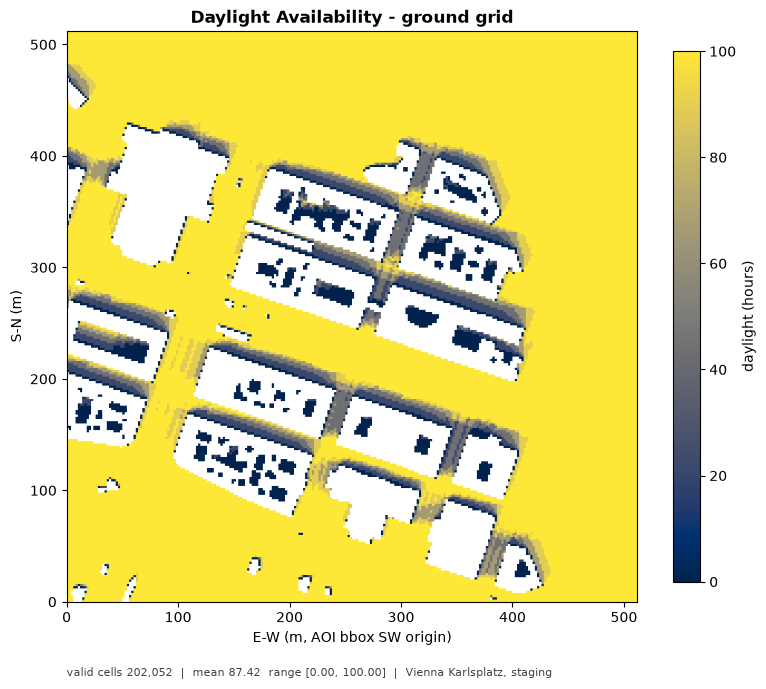

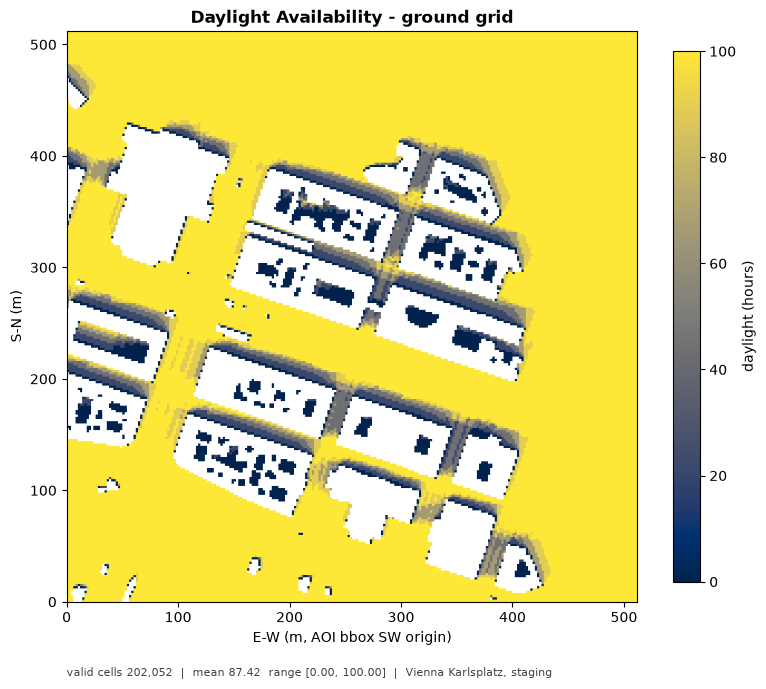

In [4]:
fig, ax = ir.grid_heatmap(
    grid,
    title="Daylight Availability - ground grid",
    cbar_label="daylight (hours)",
    cmap="cividis",
    crop=True,
    note="Vienna Karlsplatz, staging",
)
fig

## Advanced run - facade daylight sensors

`analysis-surfaces:"facades"` with partial-cell clipping. The result is the
same `surfaces` / `aggregates` / `sensor-count` shape described in notebook
`01` - one frame per facade region, `values` row-major over `nu*nv`.

In [5]:
body = da_body()
body["analysis-surfaces"] = "facades"
body["surface-grid-size"] = 4.0
body["surface-offset"] = 0.1
body["partial-cells"] = True
body["min-coverage"] = 0.25
fac_res, info = ia.run_job("daylight-availability", body, label="facades")
print("frames:", len(fac_res["surfaces"]), "| sensors:", fac_res["sensor-count"])

[daylight-availability/facades] Succeeded in 1.6s  keys=['aggregates', 'max-legend', 'min-legend', 'sensor-count', 'surfaces']  sensors=44276
frames: 2724 | sensors: 44276


### Result payload, described

Identical structure to solar radiation (see `01`):

* `surfaces["<uuid>/<idx>"]` -> `{origin, u-axis, v-axis, grid-size, nu, nv,
  values, cell-area, cell-tris, area, mean, peak}`; `values` is `nu*nv`
  row-major, `null` outside; `cell-tris` / `cell-area` aligned 1:1 with it.
* `aggregates.buildings.<uuid>` -> `{area, mean, peak}`.
* `min-legend` / `max-legend` / `sensor-count`.

Only the units differ - here `values` are daylight hours / availability, not
kWh/m2. Reconstruct the world cells exactly the same way (`reconstruct_cells`).

In [6]:
import json

fk = next(iter(fac_res["surfaces"]))
frame = fac_res["surfaces"][fk]
print("frame key:", fk)
print(
    json.dumps(
        {
            k: (v if k != "values" else v[:8] + ["...(%d)" % len(v)])
            for k, v in frame.items()
        },
        indent=2,
        default=float,
    )
)

frame key: 11155/0
{
  "origin": [
    1.6321067097250321,
    268.6121667244433,
    2.0
  ],
  "u-axis": [
    -0.2860372460124409,
    -0.9582185000789843,
    0.0
  ],
  "v-axis": [
    0.0,
    0.0,
    1.0
  ],
  "grid-size": 4.0,
  "nu": 1,
  "nv": 8,
  "values": [
    66.66666412353516,
    66.66666412353516,
    66.66666412353516,
    88.88888549804688,
    88.88888549804688,
    100.0,
    100.0,
    100.0,
    "...(8)"
  ],
  "area": 128.0,
  "mean": 84.7222204208374,
  "peak": 100.0,
  "cell-area": [
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0,
    1.0
  ],
  "cell-tris": [
    [
      2.20418119430542,
      270.5285949707031,
      0.0,
      1.4041781425476074,
      267.8486022949219,
      0.0,
      1.504178524017334,
      268.1836242675781,
      4.0,
      2.20418119430542,
      270.5285949707031,
      0.0,
      1.504178524017334,
      268.1836242675781,
      4.0,
      2.20418119430542,
      270.5285949707031,
      4.0,
      1.40417814254

## Render - colored daylight mesh on the building geometry

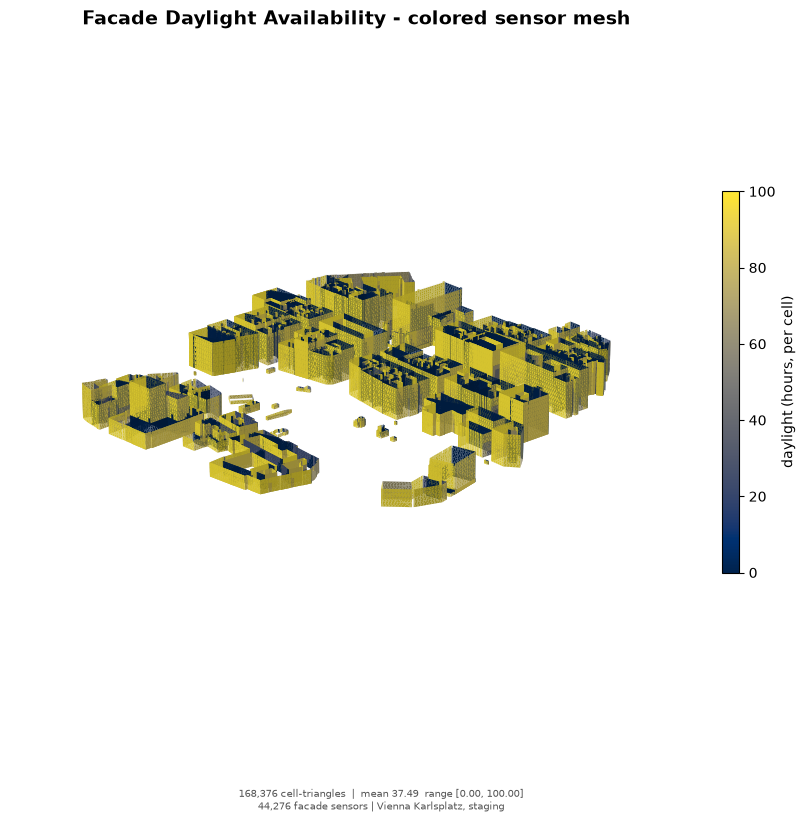

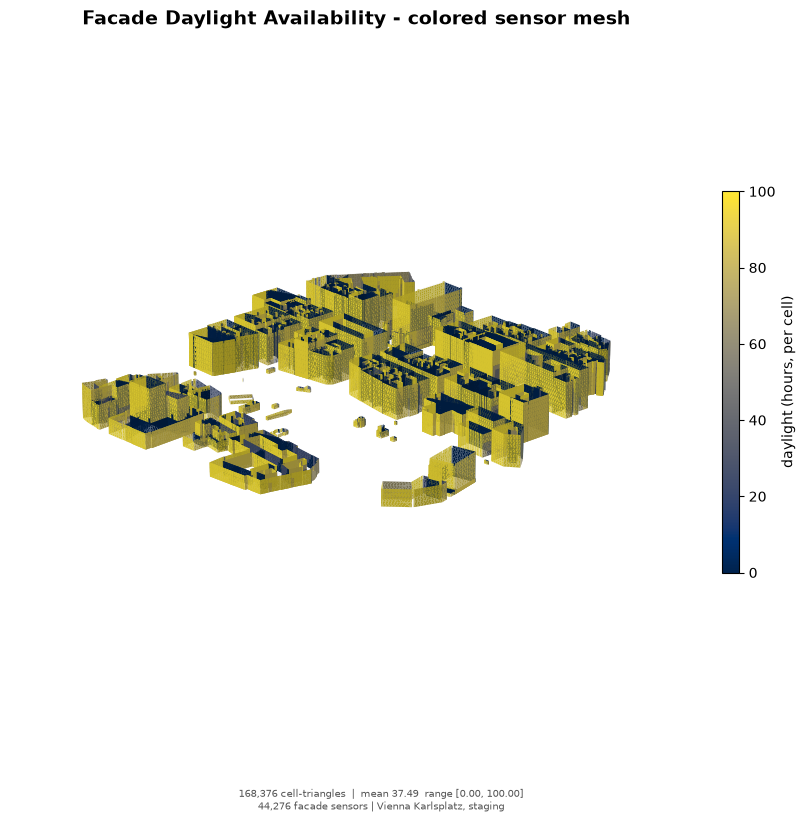

In [7]:
tris, values, normals = ia.reconstruct_cells(fac_res["surfaces"])
fig, ax = ir.surface_mesh(
    tris,
    values,
    normals=normals,
    context_faces=ia.building_faces(buildings),
    title="Facade Daylight Availability - colored sensor mesh",
    cbar_label="daylight (hours, per cell)",
    cmap="cividis",
    zmax=45,
    note=f"{fac_res['sensor-count']:,} facade sensors | Vienna Karlsplatz, staging",
)
fig

## Note - multi-month windows

Daylight (and solar / DSH / UTCI / TCS) accept **forward** multi-month and
annual windows on staging. Just widen the `TimePeriod`:

```python
tp = TimePeriod(start_month=6, start_day=1, start_hour=0,
                end_month=8, end_day=31, end_hour=23)   # Jun-Aug
```

Wrapping windows (e.g. Nov->Feb, `end-month < start-month`) are rejected with
400 - split into two forward requests. See `03` for a multi-month run.